# Demo 04 (tools) — Document Preprocessing with libraries

The runnable notebook behind **§6 (Document Preprocessing)** of *Chapter 04 — Inference-Time
Retrieval Patterns*, built on well-known libraries rather than hand-rolled code:

| §6 step | Library |
|---|---|
| Unicode / whitespace cleaning | **`ftfy`** + **`unstructured`** cleaning bricks |
| Split on headings | **LangChain** `MarkdownHeaderTextSplitter` |
| Oversized-section fallback | **LangChain** `RecursiveCharacterTextSplitter` |
| Section-path metadata | **free** — the splitter returns it in `.metadata` |

Understanding *what* each step must accomplish is the §6 lesson; leveraging a well-tested library to
do it is often the right engineering call — fewer lines, fewer bugs, portable. The closing cell
spells out what the libraries still don't do for you. Requires `ftfy`, `unstructured`,
`langchain-text-splitters` (all pip, CPU).

In [1]:
# Dependencies:
# !pip install ftfy unstructured langchain-text-splitters sentence-transformers numpy matplotlib
# No API key needed — everything runs locally on CPU.

In [2]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")   # this Mac's torch segfaults on MPS
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("HF_HUB_VERBOSITY", "error")

import warnings, logging, re, hashlib, unicodedata
warnings.filterwarnings("ignore")                   # quiet langchain's pydantic-v1 note on 3.14
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import ftfy
from unstructured.cleaners.core import clean_extra_whitespace
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

EMBED_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
_embedder = None
def embedder():
    global _embedder
    if _embedder is None:
        from sentence_transformers import SentenceTransformer
        _embedder = SentenceTransformer(EMBED_MODEL, device="cpu")
    return _embedder
def encode(texts):
    return embedder().encode(list(texts), normalize_embeddings=True)

print("tools ready:", ftfy.__name__, "+ unstructured + langchain-text-splitters")

tools ready: ftfy + unstructured + langchain-text-splitters


## 1 — The input document

Pretend this is what a PDF→Markdown extractor returned for a 3-page *Student Handbook* — Markdown
headings and a table recovered, but page furniture (running header, footer + page number) and two
hyphenated line-breaks leaked in.

In [3]:
RAW_DOC = """Bright Valley College — Student Handbook
# Course Policy
## Assignments
Assignments are released weekly on the course portal. Each assignment is due by 23:59 on the stated deadline.
### Late submission
Assignments submitted after the deadline are accepted for up to five days. Each late assign-
ment receives a penalty of 10 points per day, deducted from the final grade, with no exceptions except for documented medical emer-
gencies.
### Grading
The passing grade for every course is 60 out of 100. A final grade below 60 requires the student to retake the course.
Confidential — Internal Use Only    Page 1
Bright Valley College — Student Handbook
## Library Fees
The following fines apply to overdue library materials.
| Item type | Fine per day | Maximum fine |
| --- | --- | --- |
| Book | 2 NIS | 40 NIS |
| Laptop | 20 NIS | 300 NIS |
| Reference | 5 NIS | 90 NIS |
Figure 1. The main library reading room at Bright Valley College.
Confidential — Internal Use Only    Page 2
Bright Valley College — Student Handbook
## Vacation Policy (2022)
Students are entitled to 18 vacation days per academic year. Unused days do not carry over.
## Vacation Policy (2025)
Students are entitled to 24 vacation days per academic year. Up to 5 unused days carry over to the next year.
## Compensation (Staff — Confidential)
Teaching assistants are paid 55 NIS per hour. Senior lecturers earn a base salary of 28,000 NIS per month.
Confidential — Internal Use Only    Page 3
"""
print(f"{len(RAW_DOC)} chars, {RAW_DOC.count(chr(10))+1} lines")

1467 chars, 30 lines


## 2 — Extraction, with tools  (§6.2)

Starting from a real file you would not hand-parse it. **`unstructured`** (`partition_md`,
`partition_pdf`) turns a document into a list of typed **elements** — `Title`, `NarrativeText`,
`Table`, `Header`, `Footer` — and **Docling** / **PyMuPDF4LLM** convert PDFs straight to structured
Markdown. Two things those extraction-time tools give you that a post-hoc string cleaner cannot:
they **tag** headers/footers as such (so furniture removal is a filter, not a guess), and they keep
tables as first-class objects. That extraction layer is the subject of **`demo04_pdf_preprocessing`**;
here we begin from its Markdown output and focus on clean → chunk.

*(We don't call `partition_md` in this notebook: it pulls NLTK data at runtime, which is awkward
offline. `demo04_pdf_preprocessing` runs the real extractors.)*

## 3 — Cleaning, with tools  (§6.3)

Here is the honest split. **`ftfy.fix_text`** fixes Unicode/mojibake and normalizes to NFC in one
call; **`unstructured`'s `clean_extra_whitespace`** collapses whitespace. But **dehyphenation** and
**page-furniture removal stay custom** — no general cleaner knows that *"Bright Valley College…"* is
a running header rather than content, and joining `assign-\nment` is document-specific. (This is
exactly why furniture is better removed upstream, where the extractor has already tagged it.)

In [4]:
HEADER = "Bright Valley College — Student Handbook"

def clean_with_tools(raw: str) -> str:
    text = ftfy.fix_text(raw)                                  # [ftfy]      unicode / mojibake / NFC
    text = re.sub(r"(\w+)-\s*\n\s*(\w+)", r"\1\2", text)       # [custom]    dehyphenate line-breaks
    kept = []
    for line in text.splitlines():
        s = line.strip()
        if not s:
            continue
        if s == HEADER or s.startswith("Confidential — Internal Use Only") or s.startswith("Figure "):
            continue                                           # [custom]    drop page furniture
        kept.append(clean_extra_whitespace(line))              # [unstructured] collapse whitespace
    return "\n".join(kept)

clean_text = clean_with_tools(RAW_DOC)
print(clean_text)

# Course Policy
## Assignments
Assignments are released weekly on the course portal. Each assignment is due by 23:59 on the stated deadline.
### Late submission
Assignments submitted after the deadline are accepted for up to five days. Each late assignment receives a penalty of 10 points per day, deducted from the final grade, with no exceptions except for documented medical emergencies.
### Grading
The passing grade for every course is 60 out of 100. A final grade below 60 requires the student to retake the course.
## Library Fees
The following fines apply to overdue library materials.
| Item type | Fine per day | Maximum fine |
| --- | --- | --- |
| Book | 2 NIS | 40 NIS |
| Laptop | 20 NIS | 300 NIS |
| Reference | 5 NIS | 90 NIS |
## Vacation Policy (2022)
Students are entitled to 18 vacation days per academic year. Unused days do not carry over.
## Vacation Policy (2025)
Students are entitled to 24 vacation days per academic year. Up to 5 unused days carry over to the next year.
#

`ftfy` also covers the multilingual normalization that matters once the text isn't English: it folds
equivalent Unicode forms so search matches regardless of encoding. The **visual→logical** flip for
RTL scripts (Hebrew, Arabic) is a separate concern — the **`python-bidi`** package implements the
BiDi algorithm; below is the minimal inverse so the notebook stays install-light. (`demo13` hits
real RTL OCR output.)

In [5]:
print("ftfy folds decomposed vs composed Hebrew:",
      ftfy.fix_text(unicodedata.normalize("NFD", "שלום")) == "שלום")

HEB_RE = re.compile(r"[֐-׿]")
def visual_to_logical_hebrew(v):
    return "".join(t[::-1] if HEB_RE.search(t) else t
                   for t in re.findall(r"[֐-׿]+|[^֐-׿]+", v))
sample = "10/02/26 ןושאר םוי"
print("visual :", sample)
print("logical:", " ".join(visual_to_logical_hebrew(t) for t in sample.split()))

ftfy folds decomposed vs composed Hebrew: True
visual : 10/02/26 ןושאר םוי
logical: 10/02/26 ראשון יום


## 4 — Chunking, with LangChain  (§6.4)

The whole "detect structure, then chunk inside it" pipeline is two objects. `MarkdownHeaderTextSplitter`
splits on the headings; `RecursiveCharacterTextSplitter` only re-splits sections that exceed the size
cap. **And the section path arrives in `.metadata` for free** — no custom prefix function needed.

In [6]:
header_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[("#", "h1"), ("##", "h2"), ("###", "h3")],
    strip_headers=False,
)
sections = header_splitter.split_text(clean_text)          # -> Documents with .metadata heading path

small_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=0)
docs = small_splitter.split_documents(sections)            # re-split only oversized sections

def crumb(meta):
    return " > ".join(meta[k] for k in ("h1", "h2", "h3") if k in meta)

for d in docs:
    print(f"[{crumb(d.metadata)}]  (metadata: {d.metadata})")
print(f"\n{len(sections)} sections -> {len(docs)} chunks; the penalty answer is whole in "
      f"{sum('penalty of 10 points per day' in d.page_content for d in docs)} chunk.")

[Course Policy > Assignments]  (metadata: {'h1': 'Course Policy', 'h2': 'Assignments'})
[Course Policy > Assignments > Late submission]  (metadata: {'h1': 'Course Policy', 'h2': 'Assignments', 'h3': 'Late submission'})
[Course Policy > Assignments > Grading]  (metadata: {'h1': 'Course Policy', 'h2': 'Assignments', 'h3': 'Grading'})
[Course Policy > Library Fees]  (metadata: {'h1': 'Course Policy', 'h2': 'Library Fees'})
[Course Policy > Vacation Policy (2022)]  (metadata: {'h1': 'Course Policy', 'h2': 'Vacation Policy (2022)'})
[Course Policy > Vacation Policy (2025)]  (metadata: {'h1': 'Course Policy', 'h2': 'Vacation Policy (2025)'})
[Course Policy > Compensation (Staff — Confidential)]  (metadata: {'h1': 'Course Policy', 'h2': 'Compensation (Staff — Confidential)'})

7 sections -> 7 chunks; the penalty answer is whole in 1 chunk.


## 5 — Metadata & tables  (§6.5)

The heading path is already in `.metadata`; we enrich it with version and access flags (parsed from
the section) and fold the path into the text we embed. Table representation is the same trade-off as
before — measure Markdown vs natural-language rows on your own queries.

In [7]:
def enrich(meta):
    section = crumb(meta)
    m = {"source": "student_handbook", "doc_type": "handbook", "section": section, "access": "public"}
    if (v := re.search(r"\((\d{4})\)", section)):
        m["version"] = int(v.group(1))
    if "Confidential" in section or "Compensation" in section:
        m["access"] = "confidential"
    return m

records = [{"text": d.page_content,
            "embed_text": f"Document section: {crumb(d.metadata)}\n{d.page_content}",
            **enrich(d.metadata)} for d in docs]
for r in records:
    print({k: v for k, v in r.items() if k in ("section", "version", "access")})

table_md = next(r["text"] for r in records if "Library Fees" in r["section"])
rows = [[c.strip() for c in ln.strip().strip("|").split("|")]
        for ln in table_md.splitlines() if ln.strip().startswith("|")]
table_nl = "\n".join(f"A {r[0].lower()} has a fine of {r[1]} per day, up to {r[2]}."
                     for r in rows[2:])
q = "how much is the daily library fine for an overdue book?"
qv = encode([q])[0]
print(f"\ntable as markdown  cos={float(encode([table_md])[0] @ qv):.3f}")
print(f"table as sentences cos={float(encode([table_nl])[0] @ qv):.3f}   (measure on your corpus; often store both)")

{'section': 'Course Policy > Assignments', 'access': 'public'}
{'section': 'Course Policy > Assignments > Late submission', 'access': 'public'}
{'section': 'Course Policy > Assignments > Grading', 'access': 'public'}
{'section': 'Course Policy > Library Fees', 'access': 'public'}
{'section': 'Course Policy > Vacation Policy (2022)', 'access': 'public', 'version': 2022}
{'section': 'Course Policy > Vacation Policy (2025)', 'access': 'public', 'version': 2025}
{'section': 'Course Policy > Compensation (Staff — Confidential)', 'access': 'confidential'}

table as markdown  cos=0.675
table as sentences cos=0.614   (measure on your corpus; often store both)


## 6 — Dedup, versioning, access control  (§6.6)

**No library does these for you** — they are RAG-specific policy, not a generic text-processing
step. (At scale you'd reach for `datasketch` MinHash/LSH for near-dup detection, but the logic —
what counts as a conflict, what access tiers exist — is yours.)

In [8]:
vecs = encode([r["embed_text"] for r in records])

def sha(t): return hashlib.sha1(t.encode()).hexdigest()[:8]
exact = {}
for r in records:
    exact.setdefault(sha(r["text"]), []).append(r["section"])
print("exact-duplicate groups:", [g for g in exact.values() if len(g) > 1] or "none")

print("\nnear-duplicate pairs (cosine > 0.8):")
for i in range(len(records)):
    for j in range(i + 1, len(records)):
        if (c := float(vecs[i] @ vecs[j])) > 0.80:
            print(f"  {c:.3f}  [{records[i]['section']}] ~ [{records[j]['section']}]")

# versioning: freshest wins on conflict
qv = encode(["how many vacation days do students get?"])[0]
vac = sorted(((float(vecs[i] @ qv), records[i]) for i in range(len(records))
              if "Vacation" in records[i]["section"]), reverse=True)
print("\nfreshest version kept:", max((r for _, r in vac), key=lambda r: r["version"])["section"])

# access control: filter before retrieval
def retrieve(query, k=3, allow=("public",)):
    idx = [i for i, r in enumerate(records) if r["access"] in allow]
    qv = encode([query])[0]
    return [records[i]["section"] for _, i in
            sorted(((float(vecs[i] @ qv), i) for i in idx), reverse=True)[:k]]
q = "what is the base salary for senior lecturers?"
print("\npublic user     ->", retrieve(q, allow=("public",)))
print("authorized user ->", retrieve(q, allow=("public", "confidential")))

exact-duplicate groups: none

near-duplicate pairs (cosine > 0.8):
  0.959  [Course Policy > Vacation Policy (2022)] ~ [Course Policy > Vacation Policy (2025)]

freshest version kept: Course Policy > Vacation Policy (2025)

public user     -> ['Course Policy > Assignments > Grading', 'Course Policy > Vacation Policy (2025)', 'Course Policy > Assignments > Late submission']
authorized user -> ['Course Policy > Compensation (Staff — Confidential)', 'Course Policy > Assignments > Grading', 'Course Policy > Vacation Policy (2025)']


## 7 — Evaluate through retrieval  (§6.7)

You cannot judge preprocessing by eyeballing text — judge it by retrieval behavior. Known-answer
recall@k against a naive fixed-size baseline is the real test: does the structure-aware, library-built
pipeline actually retrieve better?

recall@1:  flat = 50%   structured (tools) = 100%
recall@2:  flat = 50%   structured (tools) = 100%


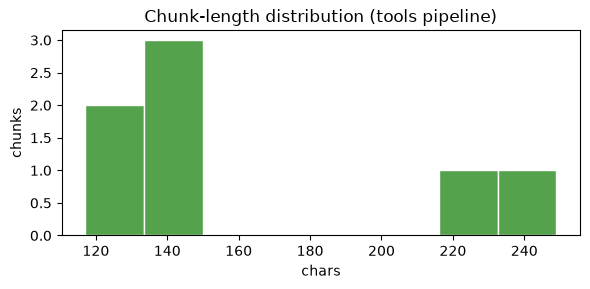

In [9]:
def fixed_size_chunks(text, size):
    return [text[i:i+size].strip() for i in range(0, len(text), size) if text[i:i+size].strip()]

gold = [
    ("What is the penalty for late submission?",       "10 points per day"),
    ("How many vacation days do students get in 2025?", "24 vacation days"),
    ("What is the passing grade?",                      "60 out of 100"),
    ("What is the daily library fine for a book?",      "2 NIS"),
]
def recall_at_k(chunks, k):
    V = encode(chunks); hits = 0
    for q, a in gold:
        order = np.argsort(-(V @ encode([q])[0]))[:k]
        hits += any(a in chunks[i] for i in order)
    return hits / len(gold)

flat = fixed_size_chunks(RAW_DOC, size=70)
structured = [r["embed_text"] for r in records]
for k in (1, 2):
    print(f"recall@{k}:  flat = {recall_at_k(flat, k):.0%}   structured (tools) = {recall_at_k(structured, k):.0%}")

lens = [len(r["text"]) for r in records]
plt.figure(figsize=(6, 3))
plt.hist(lens, bins=8, color="#54A24B", edgecolor="white")
plt.title("Chunk-length distribution (tools pipeline)"); plt.xlabel("chars"); plt.ylabel("chunks")
plt.tight_layout(); plt.show()

## 8 — Takeaways

- **Chunking + section-path metadata is a solved problem** — `MarkdownHeaderTextSplitter` +
  `RecursiveCharacterTextSplitter` give you structure-aware chunks with the heading path attached,
  for free.
- **Unicode/whitespace cleaning is a solved problem** — `ftfy` + `unstructured`'s cleaning bricks
  cover NFC, mojibake, and whitespace in a couple of calls.
- **Page-furniture removal and dehyphenation are not solved by a generic cleaner** — they're
  document-specific. The right fix is upstream, at extraction time, where the parser can tag
  headers/footers as such (PyMuPDF4LLM, Docling — see `demo04_pdf_preprocessing`).
- **Metadata policy, dedup thresholds, and evaluation design are never library work** — versioning,
  access control, and "which known-answer queries matter" all encode decisions about *your* corpus.
- **Measure preprocessing through retrieval**, not by eyeballing chunks: recall@k on known-answer
  queries is what tells you the pipeline actually works.